<a href="https://colab.research.google.com/github/roshika1235/Data_Analysis_Tasks/blob/main/Linear_Regression_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PERFORM LINEAR REGRESSION ON CAR_TRIP REAL-TIME DATASET

## IMPORT ALL NECESSARY DATASETS

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

## LOAD DATASET

In [75]:
df=pd.read_csv("/content/taxi_trip_pricing.csv")
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [77]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


## Handling NULL values

/tmp/ipykernel_697/2839810074.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Trip_Distance_km"].fillna(median,inplace=True)


<Axes: xlabel='Trip_Distance_km', ylabel='Count'>

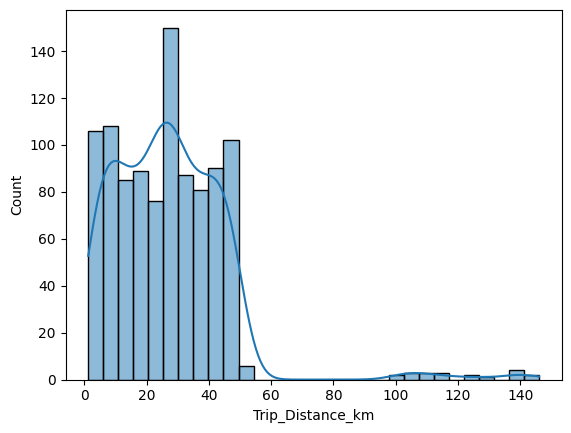

In [78]:
df["Trip_Distance_km"].isnull().sum()
df["Trip_Distance_km"].unique()
median=df["Trip_Distance_km"].median()
df["Trip_Distance_km"].fillna(median,inplace=True)
df["Trip_Distance_km"].isnull().sum()
sns.histplot(df['Trip_Distance_km'],kde=True)


## i have filled missing values with median , so that i won't get that drastic change over it

In [79]:
df['Time_of_Day'].isnull().sum()
df['Time_of_Day'].unique()
mode=df['Time_of_Day'].mode()[0]
df['Time_of_Day'].fillna(mode,inplace=True)
df['Time_of_Day'].unique()
df['Time_of_Day'].isnull().sum()

/tmp/ipykernel_697/2757460761.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time_of_Day'].fillna(mode,inplace=True)


np.int64(0)

In [80]:
df['Day_of_Week'].isnull().sum()
df['Day_of_Week'].unique()
mode=df['Day_of_Week'].mode()[0]
df['Day_of_Week'].fillna(mode,inplace=True)
df['Day_of_Week'].unique()
df['Day_of_Week'].isnull().sum()

/tmp/ipykernel_697/1040560595.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Day_of_Week'].fillna(mode,inplace=True)


np.int64(0)

In [81]:
df['Passenger_Count'].isnull().sum()
df['Passenger_Count'].unique()
mode=df['Passenger_Count'].mode()[0]
df['Passenger_Count'].fillna(mode,inplace=True)
df['Passenger_Count']=df['Passenger_Count'].astype(int)
df['Passenger_Count'].unique()
df['Passenger_Count'].isnull().sum()

/tmp/ipykernel_697/892680097.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Passenger_Count'].fillna(mode,inplace=True)


np.int64(0)

In [82]:
df['Traffic_Conditions'].isnull().sum()
df['Traffic_Conditions'].unique()
mode=df['Traffic_Conditions'].mode()[0]
df['Traffic_Conditions'].fillna(mode,inplace=True)
df['Traffic_Conditions'].unique()
df['Traffic_Conditions'].isnull().sum()

/tmp/ipykernel_697/123552385.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Traffic_Conditions'].fillna(mode,inplace=True)


np.int64(0)

In [83]:
df['Weather'].unique()
mode=df['Weather'].mode()[0]
df['Weather']=df['Weather'].fillna(mode)
df['Weather'].unique()
df['Weather'].isnull().sum()

np.int64(0)

In [84]:
df['Base_Fare'].unique()
median=df['Base_Fare'].median()
df['Base_Fare']=df['Base_Fare'].fillna(median)
df['Base_Fare'].isnull().sum()

np.int64(0)

In [85]:
df['Per_Km_Rate'].unique()
median=df['Per_Km_Rate'].median()
df['Per_Km_Rate']=df['Per_Km_Rate'].fillna(median)
df['Per_Km_Rate'].isnull().sum()

np.int64(0)

In [86]:
df['Per_Minute_Rate'].unique()
median=df['Per_Minute_Rate'].median()
df['Per_Minute_Rate']=df['Per_Minute_Rate'].fillna(median)
df['Per_Minute_Rate'].isnull().sum()

np.int64(0)

In [87]:
df['Trip_Duration_Minutes'].unique()
median=df['Trip_Duration_Minutes'].median()
df['Trip_Duration_Minutes']=df['Trip_Duration_Minutes'].fillna(median)
df['Trip_Duration_Minutes'].isnull().sum()

np.int64(0)

In [88]:
df['Trip_Price'].unique()
median=df['Trip_Price'].median()
df['Trip_Price']=df['Trip_Price'].fillna(median)
df['Trip_Price'].isnull().sum()

np.int64(0)

## EDA PROCESS

<Axes: xlabel='Time_of_Day'>

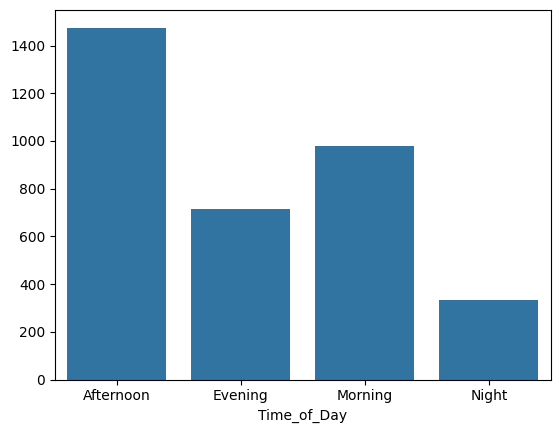

In [89]:
df_base_fare=df.groupby('Time_of_Day')['Base_Fare'].sum()
sns.barplot(x=df_base_fare.index,y=df_base_fare.values)

## generally prices are more during afternoon

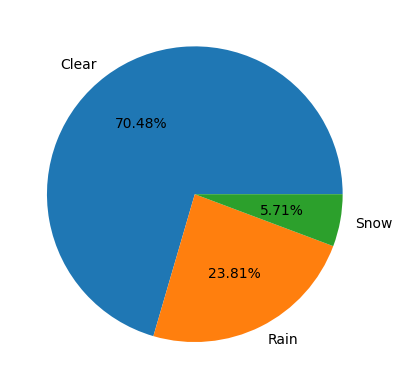

In [90]:
## in which weather the trip price is more
df_weather=df.groupby('Weather')['Trip_Price'].sum()
plt.pie(df_weather.values,labels=df_weather.index,autopct='%.2f%%')
plt.show()

## people travel more during day time , so traffic is more at that time

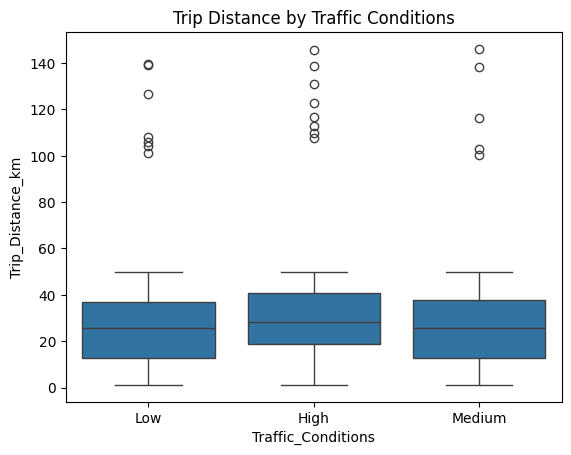

In [91]:
sns.boxplot(x="Traffic_Conditions", y="Trip_Distance_km", data=df)
plt.title("Trip Distance by Traffic Conditions")
plt.show()


## WE CAN SEE THOSE OUTLIERS , SO OUR PREDICTION MAY COME WRONGLY

In [92]:
## perform encoding on all categorical columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Time_of_Day']=le.fit_transform(df['Time_of_Day'])
df['Day_of_Week']=le.fit_transform(df['Day_of_Week'])
df['Traffic_Conditions']=le.fit_transform(df['Traffic_Conditions'])
df['Weather']=le.fit_transform(df['Weather'])

## HANDLING OUTLIERS

In [93]:
## remove outliers using IQR
def clean_outliers(col, df):
    # Find Q1 and Q3
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    # Find IQR
    iqr = q3 - q1

    # Find lower and upper bounds
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr

    # Detect outliers
    outliers = df[(df[col] < lb) | (df[col] > ub)]

    # Remove outliers
    df_cl = df[(df[col] >= lb) & (df[col] <= ub)]



    # Return both cleaned data and outliers for inspection
    return df_cl, outliers

In [94]:
## remove outliers in all cols:
for col in df.columns:
    df, outliers = clean_outliers(col, df)

In [95]:
x=df.drop("Trip_Price",axis=1)
y=df['Trip_Price']

In [97]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

## Model selection

In [98]:
model=LinearRegression()
model.fit(xtrain,ytrain)

LinearRegression()

In [99]:
ypred=model.predict(xtest)

## PERFORMANCE METRICS OF LINEAR REGRESSION

In [104]:
print("r2_score: ",r2_score(ytest,ypred))
n=df.shape[0]
p=df.shape[1]
adj_r2=1-((1-r2_score(ytest,ypred))*(n-1)/(n-p-1))
print("adjusted r2_score: ",adj_r2)
print("mse:",mean_squared_error(ytest,ypred))
print("mae:",mean_absolute_error(ytest,ypred))

r2_score:  0.8277055716227518
adjusted r2_score:  0.825727243113201
mse: 86.03264567086431
mae: 7.156608317980804


## IT IS GENERALIZING WELL , THE GAP BETWEEN TRAINING AND TESTING EFFIENCY IS SMALL

In [105]:
print("training_effiency: ",model.score(xtrain,ytrain))
print("test_effiency: ",model.score(xtest,ytest))

training_effiency:  0.8142782682237859
test_effiency:  0.8277055716227518


## PREDICTION

In [102]:
new_data=df.iloc[:1,:-1]
model.predict(new_data)

array([34.9006428])